In [1]:
!pip install transformers

Defaulting to user installation because normal site-packages is not writeable


In [1]:
from collections import Counter
import pandas as pd

df = pd.read_csv('/home/ritisha21089/btp/data/10k_phrases_batch1.csv')
all_tags = []
for label in df["Labels"]:
    all_tags.extend(eval(label))  # Convert string representation of list to actual list

tag_counts = Counter(all_tags)

print(tag_counts)

Counter({'O': 25986, 'NAME': 17391, 'STATE': 11788, 'QUANTITY': 10150, 'UNIT': 7478, 'DF': 724, 'SIZE': 638, 'FORM': 619, 'PREPROCESSING': 6})


In [4]:
# Drop rows containing "PREPROCESSING" in the Labels column
df_filtered = df[~df["Labels"].apply(lambda labels: "PREPROCESSING" in labels)]

# Display the filtered DataFrame
print(df_filtered)

                                     Ingredient_Phrases Quantity      Unit  \
0                               5 ounces spinach leaves        5    ounces   
1     1 teaspoon wheat germ , if desired -LRB- optio...        1  teaspoon   
2                1/8 cup pine nuts -LRB- optional -RRB-      1/8       cup   
3                                 1/4 cup sunflower oil      1/4       cup   
4       1 batch jerk sauce -LRB- see recipe above -RRB-        1     batch   
...                                                 ...      ...       ...   
9495                     1 lemongrass -LRB- sereh -RRB-        1       NaN   
9496                   4 ounces anchovies packed in oil        4    ounces   
9497  1 baguette -LRB- or other crusty loaf of bread...        1       NaN   
9498       12 toothpicks -LRB- soak them in water -RRB-       12       NaN   
9499                     10 tortillas -LRB- about -RRB-       10       NaN   

              Ingredient Name    Form               State Dry/F

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.pyplot as plt
import transformers
from transformers import AutoTokenizer
from transformers import  BertForTokenClassification

from torch.optim import AdamW

import torch
import torch.nn as nn
from torch.optim import SGD
import torch.nn.functional as F
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score,f1_score, precision_score, recall_score

In [3]:
class DistilbertNER(nn.Module):
  """
  Implement NN class based on distilbert pretrained from Hugging face.
  Inputs : 
    tokens_dim : int specifyng the dimension of the classifier
  """
  
  def __init__(self, tokens_dim):
    super(DistilbertNER,self).__init__()
    
    if type(tokens_dim) != int:
            raise TypeError('Please tokens_dim should be an integer')

    if tokens_dim <= 0:
          raise ValueError('Classification layer dimension should be at least 1')

    self.pretrained = BertForTokenClassification.from_pretrained("bert-base-cased", num_labels = tokens_dim) 

  def forward(self, input_ids, attention_mask, labels = None):
    """
  Forwad computation of the network
  Input:
    - inputs_ids : from model tokenizer
    - attention :  mask from model tokenizer
    - labels : if given the model is able to return the loss value
  """

    #inference time no labels
    if labels == None:
      out = self.pretrained(input_ids = input_ids, attention_mask = attention_mask )
      return out

    out = self.pretrained(input_ids = input_ids, attention_mask = attention_mask , labels = labels)
    return out

In [4]:
class NerDataset(torch.utils.data.Dataset):
    """
    Custom dataset implementation to get (text, labels) tuples
    """
    def __init__(self, df):
        if not isinstance(df, pd.DataFrame):
            raise TypeError('Input should be a dataframe')
            
        texts = df["Ingredient_Phrases"].values.tolist()
        tags_list = [i.split() for i in df["Labels"].values.tolist()]

        self.texts = [tokenizer(text, padding="max_length", truncation=True, return_tensors="pt") for text in texts]
        self.labels = [match_tokens_labels(text, tags) for text, tags in zip(self.texts, tags_list)]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        batch_text = self.texts[idx]
        batch_labels = self.labels[idx]

        return batch_text, torch.LongTensor(batch_labels)

In [5]:
class MetricsTracking():
  """
  In order make the train loop lighter I define this class to track all the metrics that we are going to measure for our model.
  """
  def __init__(self):

    self.total_acc = 0
    self.total_f1 = 0
    self.total_precision = 0
    self.total_recall = 0

  def update(self, predictions, labels , ignore_token = -100):
    '''
    Call this function every time you need to update your metrics.
    Where in the train there was a -100, were additional token that we dont want to label, so remove them.
    If we flatten the batch its easier to access the indexed = -100
    '''  
    predictions = predictions.flatten()
    labels = labels.flatten()
    
    predictions = predictions[labels != ignore_token]
    labels = labels[labels != ignore_token]

    predictions = predictions.to("cpu")
    labels = labels.to("cpu")

    acc = accuracy_score(labels,predictions)
    f1 = f1_score(labels, predictions, average = "macro")
    precision = precision_score(labels, predictions, average = "macro")
    recall = recall_score(labels, predictions, average = "macro")

    self.total_acc  += acc
    self.total_f1 += f1
    self.total_precision += precision
    self.total_recall  += recall

  def return_avg_metrics(self,data_loader_size):
    n = data_loader_size
    metrics = {
        "acc": round(self.total_acc / n ,3), 
        "f1": round(self.total_f1 / n, 3), 
        "precision" : round(self.total_precision / n, 3), 
        "recall": round(self.total_recall / n, 3)
          }
    return metrics   

In [6]:
def match_tokens_labels(tokenized_input, tags, ignore_token=-100):
    word_ids = tokenized_input.word_ids()
    previous_word_idx = None
    label_ids = []

    for word_idx in word_ids:
        if word_idx is None:
            label_ids.append(ignore_token)
        else:
            try:
                reference_tag = tags[word_idx]
                label_ids.append(tag2idx[reference_tag])
            except:
                label_ids.append(ignore_token)

        previous_word_idx = word_idx

    return label_ids
    
def tags_mapping(tags_series):
    unique_tags = set()

    for tag_list in tags_series:
        for tag in tag_list.split():
            unique_tags.add(tag)

    tag2idx = {k: v for v, k in enumerate(sorted(unique_tags))}
    idx2tag = {v: k for v, k in tag2idx.items()}

    unseen_label = tag2idx["O"]

    return tag2idx, idx2tag, unseen_label, unique_tags

In [7]:
def freeze_model(model,num_layers = 1):
  """
  Freeze last num_layers of a model to prevent ctastrophic forgetting.
  Doesn't seem to work weel, its better to fine tune the entire netwok
  """
  for id , params in enumerate(model.parameters()):
    if id == len(list(model.parameters())) - num_layers: 
      print("last layer unfreezed")
      params.requires_grad = True
    else:
      params.requires_grad = False
  return model

In [8]:
def train_loop(model, train_dataset, dev_dataset, optimizer,  batch_size, epochs):

  train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
  dev_dataloader = DataLoader(dev_dataset, batch_size = batch_size, shuffle = True)

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model = model.to(device)

  train_metrics_list = {'loss':[], 'acc':[], 'precision':[], 'recall':[], 'f1':[] }
  test_metrics_list = {'loss':[], 'acc':[], 'precision':[], 'recall':[], 'f1':[] }



  for epoch in range(epochs): 
    
    train_metrics = MetricsTracking()
    total_loss_train = 0

    model.train() #train mode

    for train_data, train_label in tqdm(train_dataloader):

      train_label = train_label.to(device)
      '''
      squeeze in order to match the sizes. From [batch,1,seq_len] --> [batch,seq_len] 
      '''
      mask = train_data['attention_mask'].squeeze(1).to(device)
      input_id = train_data['input_ids'].squeeze(1).to(device)

      optimizer.zero_grad()
      
      output = model(input_id, mask, train_label)
      loss, logits = output.loss, output.logits
      predictions = logits.argmax(dim= -1) 

      #computing metrics
      train_metrics.update(predictions, train_label)
      total_loss_train += loss.item()

      #grad step
      loss.backward()
      optimizer.step()
    
    '''
    EVALUATION MODE
    '''            
    model.eval()

    dev_metrics = MetricsTracking()
    total_loss_dev = 0
    
    with torch.no_grad():
      for dev_data, dev_label in dev_dataloader:

        dev_label = dev_label.to(device)

        mask = dev_data['attention_mask'].squeeze(1).to(device)
        input_id = dev_data['input_ids'].squeeze(1).to(device)

        output = model(input_id, mask, dev_label)
        loss, logits = output.loss, output.logits

        predictions = logits.argmax(dim= -1)     

        dev_metrics.update(predictions, dev_label)
        total_loss_dev += loss.item()
    
    train_results = train_metrics.return_avg_metrics(len(train_dataloader))
    dev_results = dev_metrics.return_avg_metrics(len(dev_dataloader))

    train_metrics_list['loss'].append(total_loss_train / len(train_dataset))
    train_metrics_list['acc'].append(train_results['acc'])
    train_metrics_list['precision'].append(train_results['precision'])
    train_metrics_list['recall'].append(train_results['recall'])
    train_metrics_list['f1'].append(train_results['f1'])

    test_metrics_list['loss'].append(total_loss_dev / len(dev_dataset))
    test_metrics_list['acc'].append(dev_results['acc'])
    test_metrics_list['precision'].append(dev_results['precision'])
    test_metrics_list['recall'].append(dev_results['recall'])
    test_metrics_list['f1'].append(dev_results['f1'])

    print(f"TRAIN \nLoss: {total_loss_train / len(train_dataset)} \nMetrics {train_results}\n" ) 
    print(f"VALIDATION \nLoss {total_loss_dev / len(dev_dataset)} \nMetrics{dev_results}\n" )
  return train_metrics_list, test_metrics_list

In [8]:
from sklearn.model_selection import train_test_split
df_new = pd.read_csv('./NEW_Annotated_Dataset_NER.csv')


df_train, df_test = train_test_split(df_new, test_size=0.2, random_state=42)

df_dev = df_test  

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [9]:
import re

# Function to clean the labels
def clean_labels(label_column):
    cleaned_labels = []
    for label_list in label_column:
        cleaned_label = re.sub(r"[\[\]']", "", label_list)
        cleaned_label = cleaned_label.replace(",", "") 
        cleaned_labels.append(cleaned_label.strip()) 
    return cleaned_labels

df_train["Labels"] = clean_labels(df_train["Labels"])
df_test["Labels"] = clean_labels(df_test["Labels"])

# Checking the unique cleaned labels
print(df_train["Labels"].unique())

['QUANTITY NAME O STATE STATE O'
 'QUANTITY UNIT DF NAME FORM O STATE STATE'
 'O O O O O O O O O O O O O O O O' ... 'QUANTITY UNIT O O NAME O O O'
 'QUANTITY UNIT O NAME NAME O O O O O O O O O O NAME O O O O O'
 'QUANTITY NAME NAME O QUANTITY O O O']


In [10]:
#tag-label mapping
tag2idx, idx2tag , unseen_label, unique_tags = tags_mapping(df_train["Labels"])

def tags_2_labels(tags: str, tag2idx: dict):
    return [tag2idx[tag] if tag in tag2idx else unseen_label for tag in tags.split()]
for df in [df_train, df_dev, df_test]:
    df["labels"] = df["Labels"].apply(lambda tags: tags_2_labels(tags, tag2idx))

In [11]:
# Ensuring all entries in 'Ingredient_Phrases' are strings
df_train["Ingredient_Phrases"] = df_train["Ingredient_Phrases"].astype(str)

df_train = df_train[df_train["Ingredient_Phrases"].str.strip() != '']  
df_train = df_train.dropna(subset=["Ingredient_Phrases"])  

text_tokenized = tokenizer(df_train["Ingredient_Phrases"].values.tolist(),padding='max_length', truncation=True, return_tensors="pt")

In [13]:
model = DistilbertNER(len(unique_tags))

#datasets
train_dataset = NerDataset(df_train)
dev_dataset = NerDataset(df_dev)

lr = 1e-2
optimizer = SGD(model.parameters(), lr=lr, momentum = 0.9)  

#MAIN
parameters = {
    "model": model,
    "train_dataset": train_dataset,
    "dev_dataset" : dev_dataset,
    "optimizer" : optimizer,
    "batch_size" : 32,
    "epochs" : 8
}

train_metrics_list, test_metrics_list = train_loop(**parameters)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 238/238 [02:27<00:00,  1.61it/s]


TRAIN 
Loss: 0.01661910838986698 
Metrics {'acc': 0.825, 'f1': 0.693, 'precision': 0.723, 'recall': 0.691}

VALIDATION 
Loss 0.011074555351545936 
Metrics{'acc': 0.888, 'f1': 0.816, 'precision': 0.852, 'recall': 0.815}



100%|██████████| 238/238 [02:27<00:00,  1.61it/s]


TRAIN 
Loss: 0.0096729262624132 
Metrics {'acc': 0.899, 'f1': 0.816, 'precision': 0.841, 'recall': 0.818}

VALIDATION 
Loss 0.009270962892394317 
Metrics{'acc': 0.908, 'f1': 0.859, 'precision': 0.891, 'recall': 0.851}



100%|██████████| 238/238 [02:27<00:00,  1.61it/s]


...

TRAIN 
Loss: 0.005006882524313895 
Metrics {'acc': 0.945, 'f1': 0.896, 'precision': 0.907, 'recall': 0.904}

VALIDATION 
Loss 0.009214036550961043 
Metrics{'acc': 0.917, 'f1': 0.883, 'precision': 0.889, 'recall': 0.896}



100%|██████████| 238/238 [02:27<00:00,  1.61it/s]


TRAIN 
Loss: 0.004145591182046031 
Metrics {'acc': 0.954, 'f1': 0.916, 'precision': 0.922, 'recall': 0.925}

VALIDATION 
Loss 0.009711420155669514 
Metrics{'acc': 0.919, 'f1': 0.895, 'precision': 0.895, 'recall': 0.915}



100%|██████████| 238/238 [02:27<00:00,  1.62it/s]


TRAIN 
Loss: 0.003755672632373477 
Metrics {'acc': 0.957, 'f1': 0.926, 'precision': 0.933, 'recall': 0.934}

VALIDATION 
Loss 0.009895009759225344 
Metrics{'acc': 0.917, 'f1': 0.886, 'precision': 0.895, 'recall': 0.896}



In [14]:
train_metrics_list 

{'loss': [0.01661910838986698,
  0.0096729262624132,
  0.007863239978293055,
  0.006594498305532493,
  0.00564821551504888,
  0.005006882524313895,
  0.004145591182046031,
  0.003755672632373477],
 'acc': [0.825, 0.899, 0.917, 0.928, 0.938, 0.945, 0.954, 0.957],
 'precision': [0.723, 0.841, 0.873, 0.895, 0.903, 0.907, 0.922, 0.933],
 'recall': [0.691, 0.818, 0.861, 0.888, 0.904, 0.904, 0.925, 0.934],
 'f1': [0.693, 0.816, 0.855, 0.882, 0.894, 0.896, 0.916, 0.926]}

# BERT MODEL

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, BertForTokenClassification, AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


# BERT-based NER class
class BertNER(nn.Module):
    def __init__(self, tokens_dim):
        super(BertNER, self).__init__()
        
        if type(tokens_dim) != int:
            raise TypeError('tokens_dim should be an integer')
        if tokens_dim <= 0:
            raise ValueError('Classification layer dimension should be at least 1')

        self.pretrained = BertForTokenClassification.from_pretrained("bert-base-cased", num_labels=tokens_dim)

    def forward(self, input_ids, attention_mask, labels=None):
        """
        Forward pass of the network.
        """
        if labels is None:
            return self.pretrained(input_ids=input_ids, attention_mask=attention_mask)
        return self.pretrained(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    
    def save_pretrained(self, save_directory):
        """
        Save the pretrained model to the specified directory.
        """
        self.pretrained.save_pretrained(save_directory)

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, RobertaForTokenClassification, AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


# RoBERTa-based NER class
class RobertaNER(nn.Module):
    def __init__(self, tokens_dim):
        super(RobertaNER, self).__init__()
        
        if type(tokens_dim) != int:
            raise TypeError('tokens_dim should be an integer')
        if tokens_dim <= 0:
            raise ValueError('Classification layer dimension should be at least 1')

        # Use RoBERTa large model for token classification
        self.pretrained = RobertaForTokenClassification.from_pretrained("roberta-large", num_labels=tokens_dim)

    def forward(self, input_ids, attention_mask, labels=None):
        """
        Forward pass of the network.
        """
        if labels is None:
            return self.pretrained(input_ids=input_ids, attention_mask=attention_mask)
        return self.pretrained(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    
    def save_pretrained(self, save_directory):
        """
        Save the pretrained model to the specified directory.
        """
        self.pretrained.save_pretrained(save_directory)


# Initialize the tokenizer for RoBERTa
tokenizer = AutoTokenizer.from_pretrained("roberta-large")

In [9]:
import torch
from torch.utils.data import Dataset
import ast

class NerDataset(Dataset):
    """
    Custom dataset class for NER tasks.
    """

    def __init__(self, dataframe, tokenizer, label_map, max_len=128):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.label_map = label_map
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        # Ensure the 'Ingredient_Phrases' column is a string
        text = str(row['Ingredient_Phrases'])

        # Convert 'Labels' from string representation to a list
        labels_list = ast.literal_eval(row['Labels'])  

        encoding = self.tokenizer(
            text.split(),  # Tokenize word by word
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
            is_split_into_words=True  # Ensure token alignment with words
        )

        word_ids = encoding.word_ids(batch_index=0)  # Get token-word alignment
        label_ids = [-100] * self.max_len  # Default to ignored token

        # Assigning NER labels for each word token
        previous_word_id = None
        for i, word_id in enumerate(word_ids):
            if word_id is None:
                label_ids[i] = -100  # Padding or special tokens
            elif word_id != previous_word_id:
                label_ids[i] = self.label_map.get(labels_list[word_id], -100)  # Assign the correct label
            else:
                label_ids[i] = label_ids[i-1]  # For subwords, keep same label
            previous_word_id = word_id

        input_ids = encoding['input_ids'].squeeze(0)  # Remove batch dimension
        attention_mask = encoding['attention_mask'].squeeze(0)  # Remove batch dimension
        label_ids = torch.tensor(label_ids, dtype=torch.long)  # Convert to tensor

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': label_ids
        }

# Label mapping 
label_map = {
    'QUANTITY': 0,
    'UNIT': 1,
    'NAME': 2,
    'FORM': 3,
    'STATE': 4,
    'DF': 5,
    'SIZE': 6,
    'PREPROCESSING': 7,
    'O': -100  # Outside token or padding
}

In [ ]:
class NerDataset(Dataset):
    """
    Custom dataset class for NER tasks.
    """

    def __init__(self, dataframe, tokenizer, label_map, max_len=128):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.label_map = label_map
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        # to ensure the 'Ingredient_Phrases' column is a string
        text = str(row['Ingredient_Phrases'])

        labels = row['Labels']

        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
            return_attention_mask=True,
            is_split_into_words=False
        )

        # Converting labels to match tokenization
        label_ids = [-100] * self.max_len 
        word_ids = encoding.word_ids()

        labels_list = eval(labels)  

        # Assigning NER labels for each word
        for i, word_id in enumerate(word_ids):
            if word_id is None or word_id >= len(labels_list):
                label_ids[i] = -100
            else:
                label_ids[i] = self.label_map.get(labels_list[word_id], -100)

        input_ids = encoding['input_ids'].flatten()
        attention_mask = encoding['attention_mask'].flatten()
        label_ids = torch.tensor(label_ids)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': label_ids
        }

# Label mapping 
label_map = {
    'QUANTITY': 0,
    'UNIT': 1,
    'NAME': 2,
    'FORM': 3,
    'STATE': 4,
    'DF': 5,
    'SIZE': 6,
    'PREPROCESSING': 7,
    'O': -100  # Outside token or padding
}



In [ ]:
# tokens_dim = len(label_map) 
# model = BertNER(tokens_dim=tokens_dim)
# optimizer = AdamW(model.parameters(), lr=2e-5) 
# epochs = 8
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

In [10]:
from sklearn.model_selection import train_test_split
df = pd.read_csv('/home/ritisha21089/btp/data/6500_dataset.csv')

#ner_dataset = NerDataset(df, tokenizer, label_map)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
#data_loader = DataLoader(ner_dataset, batch_size=16, shuffle=True)

train_dataset = NerDataset(dataframe=train_df, tokenizer=tokenizer, label_map=label_map, max_len=128)
test_dataset = NerDataset(dataframe=test_df, tokenizer=tokenizer, label_map=label_map, max_len=128)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


model = BertNER(tokens_dim=len(label_map))
# model = RobertaNER(tokens_dim=len(label_map))


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# from sklearn.model_selection import train_test_split
# from torch.utils.data import DataLoader, random_split

# # Split the train_df further into training and validation sets
# train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
# train_split, val_split = train_test_split(train_df, test_size=0.2, random_state=42)

# # Create datasets for train, validation, and test sets
# train_dataset = NerDataset(dataframe=train_split, tokenizer=tokenizer, label_map=label_map, max_len=128)
# val_dataset = NerDataset(dataframe=val_split, tokenizer=tokenizer, label_map=label_map, max_len=128)
# test_dataset = NerDataset(dataframe=test_df, tokenizer=tokenizer, label_map=label_map, max_len=128)

# # Create data loaders for train, validation, and test sets
# train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
# val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)
# test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# # Verify the setup
# train_loader_info = len(train_dataloader), len(val_dataloader), len(test_dataloader)
# train_loader_info 

(321, 81, 101)

In [11]:
optimizer = AdamW(model.parameters(), lr=2e-5)

# Training settings
epochs = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.train()

/home/ritisha21089/miniconda3/lib/python3.9/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [7]:
print(device)

cuda


Epoch 1/10, Training Loss: 0.1505, Validation Loss: 0.1211
Epoch 2/10, Training Loss: 0.1070, Validation Loss: 0.1134
Epoch 3/10, Training Loss: 0.0795, Validation Loss: 0.1235
Epoch 4/10, Training Loss: 0.0603, Validation Loss: 0.1297
Epoch 5/10, Training Loss: 0.0470, Validation Loss: 0.1325
Epoch 6/10, Training Loss: 0.0373, Validation Loss: 0.1395
Epoch 7/10, Training Loss: 0.0321, Validation Loss: 0.1482
Epoch 8/10, Training Loss: 0.0238, Validation Loss: 0.1695
Epoch 9/10, Training Loss: 0.0191, Validation Loss: 0.1638
Epoch 10/10, Training Loss: 0.0203, Validation Loss: 0.1461


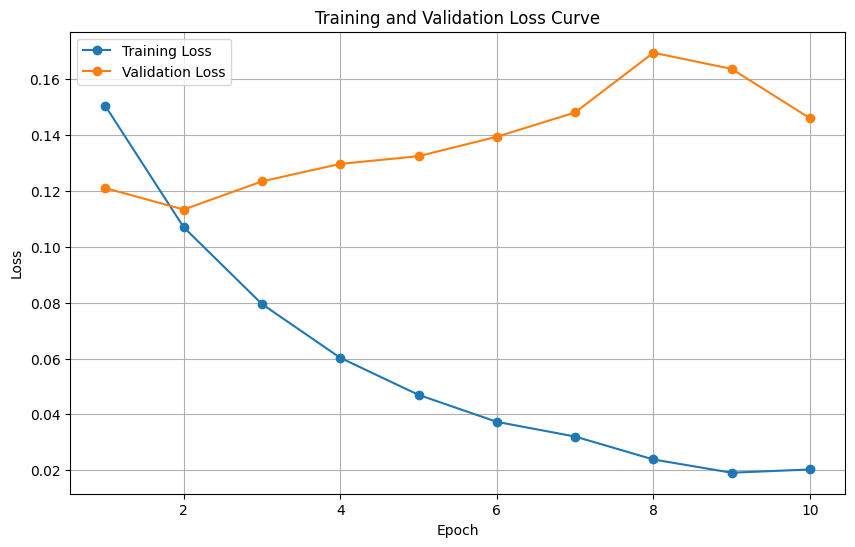

In [ ]:
# # Track training and validation loss
# training_loss = []
# validation_loss = []

# # Training loop
# for epoch in range(epochs):
#     # Training
#     model.train()
#     total_train_loss = 0

#     for batch in train_dataloader:
#         optimizer.zero_grad()

#         input_ids = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         labels = batch['labels'].to(device)

#         # Forward pass
#         outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
#         loss = outputs.loss

#         # Backward pass and optimization
#         loss.backward()
#         optimizer.step()

#         total_train_loss += loss.item()

#     avg_train_loss = total_train_loss / len(train_dataloader)
#     training_loss.append(avg_train_loss)

#     # Validation
#     model.eval()
#     total_val_loss = 0

#     with torch.no_grad():
#         for batch in val_dataloader:
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             labels = batch['labels'].to(device)

#             outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
#             loss = outputs.loss

#             total_val_loss += loss.item()

#     avg_val_loss = total_val_loss / len(val_dataloader)
#     validation_loss.append(avg_val_loss)

#     print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

# # Plot the loss curves
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))
# plt.plot(range(1, epochs + 1), training_loss, label='Training Loss', marker='o')
# plt.plot(range(1, epochs + 1), validation_loss, label='Validation Loss', marker='o')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Training and Validation Loss Curve')
# plt.legend()
# plt.grid()
# plt.show()

In [ ]:
# model.eval()
# predictions = []
# true_labels = []

# with torch.no_grad():
#     for batch in test_loader:
#         input_ids = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         labels = batch['labels'].to(device)

#         outputs = model(input_ids=input_ids, attention_mask=attention_mask)
#         logits = outputs.logits

#         logits = logits.detach().cpu().numpy()
#         label_ids = labels.cpu().numpy()

#         for i in range(len(label_ids)):
#             pred_labels = []
#             true_label = []
#             for j in range(len(label_ids[i])):
#                 if label_ids[i][j] != -100:
#                     true_label.append(label_ids[i][j])
#                     pred_label = np.argmax(logits[i][j])
#                     pred_labels.append(pred_label)
#             predictions.append(pred_labels)
#             true_labels.append(true_label)

In [8]:
# train
for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# Evaluation 
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        logits = logits.detach().cpu().numpy()
        label_ids = labels.cpu().numpy()

        for i in range(len(label_ids)):
            pred_labels = []
            true_label = []
            for j in range(len(label_ids[i])):
                if label_ids[i][j] != -100:
                    true_label.append(label_ids[i][j])
                    pred_label = np.argmax(logits[i][j])
                    pred_labels.append(pred_label)
            predictions.append(pred_labels)
            true_labels.append(true_label)

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [11]:
from sklearn.metrics import classification_report

# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels, flat_predictions, digits=4)
print(report)

Precision: 0.9416
Recall: 0.9260
F1-Score: 0.9331
              precision    recall  f1-score   support

           0     0.9917    0.9869    0.9893      2054
           1     0.9752    0.9865    0.9808      2150
           2     0.9698    0.9716    0.9707      5523
           3     0.7961    0.8200    0.8079       200
           4     0.9572    0.9541    0.9556      3138
           5     0.9660    0.9530    0.9595       149
           6     0.9350    0.8099    0.8679       142

    accuracy                         0.9680     13356
   macro avg     0.9416    0.9260    0.9331     13356
weighted avg     0.9681    0.9680    0.9680     13356



In [ ]:
# # Label mapping 
# label_map = {
#     'QUANTITY': 0,
#     'UNIT': 1,
#     'NAME': 2,
#     'FORM': 3,
#     'STATE': 4,
#     'DF': 5,
#     'SIZE': 6,
#     'PREPROCESSING': 7,
#     'O': -100  # Outside token or padding
# }

In [1]:
# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, Dataset
# from transformers import AutoTokenizer, BloomForTokenClassification, AdamW
# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


# # BLOOM-based NER class
# class BloomNER(nn.Module):
#     def __init__(self, tokens_dim):
#         super(BloomNER, self).__init__()
        
#         if type(tokens_dim) != int:
#             raise TypeError('tokens_dim should be an integer')
#         if tokens_dim <= 0:
#             raise ValueError('Classification layer dimension should be at least 1')

#         # Use BLOOM model for token classification
#         self.pretrained = BloomForTokenClassification.from_pretrained("bigscience/bloom", num_labels=tokens_dim)

#     def forward(self, input_ids, attention_mask, labels=None):
#         """
#         Forward pass of the network.
#         """
#         if labels is None:
#             return self.pretrained(input_ids=input_ids, attention_mask=attention_mask)
#         return self.pretrained(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    
#     def save_pretrained(self, save_directory):
#         """
#         Save the pretrained model to the specified directory.
#         """
#         self.pretrained.save_pretrained(save_directory)


# # Initialize the tokenizer for BLOOM
# tokenizer = AutoTokenizer.from_pretrained("bigscience/bloom")

In [6]:
# roberta
# train
for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# Evaluation 
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        logits = logits.detach().cpu().numpy()
        label_ids = labels.cpu().numpy()

        for i in range(len(label_ids)):
            pred_labels = []
            true_label = []
            for j in range(len(label_ids[i])):
                if label_ids[i][j] != -100:
                    true_label.append(label_ids[i][j])
                    pred_label = np.argmax(logits[i][j])
                    pred_labels.append(pred_label)
            predictions.append(pred_labels)
            true_labels.append(true_label)

Epoch 1/8, Loss: 0.2633
Epoch 2/8, Loss: 0.1613
Epoch 3/8, Loss: 0.1459
Epoch 4/8, Loss: 0.0982
Epoch 5/8, Loss: 0.0681
Epoch 6/8, Loss: 0.0543
Epoch 7/8, Loss: 0.0573
Epoch 8/8, Loss: 0.0562


In [ ]:
from sklearn.metrics import classification_report

# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels, flat_predictions, digits=4)
print(report)


roberta

Precision: 0.9386
Recall: 0.9383
F1-Score: 0.9379
              precision    recall  f1-score   support

           0     0.9922    0.9884    0.9903      2067
           1     0.9863    0.9768    0.9815      1551
           2     0.9763    0.9690    0.9726      4545
           3     0.8552    0.7702    0.8105       161
           4     0.9447    0.9657    0.9551      2744
           5     0.9021    0.9699    0.9348       133
           6     0.9134    0.9280    0.9206       125

    accuracy                         0.9695     11326
   macro avg     0.9386    0.9383    0.9379     11326
weighted avg     0.9696    0.9695    0.9695     11326



ran for the bucket analysis

In [5]:
# train
for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# Evaluation 
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        logits = logits.detach().cpu().numpy()
        label_ids = labels.cpu().numpy()

        for i in range(len(label_ids)):
            pred_labels = []
            true_label = []
            for j in range(len(label_ids[i])):
                if label_ids[i][j] != -100:
                    true_label.append(label_ids[i][j])
                    pred_label = np.argmax(logits[i][j])
                    pred_labels.append(pred_label)
            predictions.append(pred_labels)
            true_labels.append(true_label)

Epoch 1/8, Loss: 0.2886
Epoch 2/8, Loss: 0.1117
Epoch 3/8, Loss: 0.0764
Epoch 4/8, Loss: 0.0548
Epoch 5/8, Loss: 0.0399
Epoch 6/8, Loss: 0.0320
Epoch 7/8, Loss: 0.0252
Epoch 8/8, Loss: 0.0237


ran for 8 epochs

ran for error analysis

In [ ]:
from sklearn.metrics import classification_report

# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels, flat_predictions, digits=4)
print(report)

Precision: 0.9317
Recall: 0.9403
F1-Score: 0.9348
              precision    recall  f1-score   support

           0     0.9889    0.9875    0.9882      2077
           1     0.9862    0.9853    0.9857      2174
           2     0.9718    0.9717    0.9717      5468
           3     0.8763    0.7725    0.8212       211
           4     0.9541    0.9550    0.9546      3181
           5     0.8363    0.9728    0.8994       147
           6     0.9084    0.9370    0.9225       127

    accuracy                         0.9689     13385
   macro avg     0.9317    0.9403    0.9348     13385
weighted avg     0.9690    0.9689    0.9689     13385



              precision    recall  f1-score      support
0              0.988910  0.987482  0.988196   2077.00000
1              0.986188  0.985281  0.985734   2174.00000
2              0.971831  0.971653  0.971742   5468.00000
3              0.876344  0.772512  0.821159    211.00000
4              0.954146  0.955046  0.954595   3181.00000
5              0.836257  0.972789  0.899371    147.00000
6              0.908397  0.937008  0.922481    127.00000
accuracy       0.968920  0.968920  0.968920      0.96892
macro avg      0.931725  0.940253  0.934754  13385.00000
weighted avg   0.969014  0.968920  0.968857  13385.00000


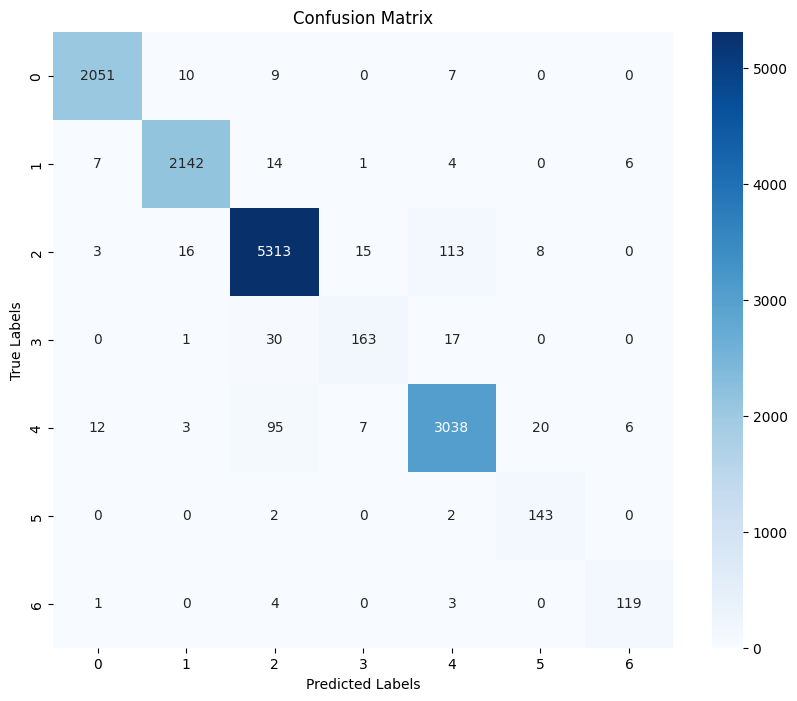

Total Misclassified Examples: 416
Sample Misclassified Examples:
True: 2, Predicted: 3
True: 1, Predicted: 0
True: 4, Predicted: 5
True: 2, Predicted: 4
True: 0, Predicted: 4
True: 2, Predicted: 4
True: 2, Predicted: 4
True: 2, Predicted: 4
True: 2, Predicted: 4
True: 1, Predicted: 2

Misclassification Frequency:
True Label  Predicted Label
2           4                  113
4           2                   95
3           2                   30
4           5                   20
3           4                   17
2           1                   16
            3                   15
1           2                   14
4           0                   12
0           1                   10
            2                    9
2           5                    8
4           3                    7
1           0                    7
0           4                    7
1           6                    6
4           6                    6
1           4                    4
6           2              

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming flat_predictions and flat_true_labels are already defined

# Generate Classification Report
report = classification_report(flat_true_labels, flat_predictions, digits=4, output_dict=True)
print(pd.DataFrame(report).transpose())  # Display the detailed report

# Confusion Matrix
conf_matrix = confusion_matrix(flat_true_labels, flat_predictions)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(flat_true_labels),
            yticklabels=np.unique(flat_true_labels))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Error Analysis: Misclassified Examples
errors = [(true, pred) for true, pred in zip(flat_true_labels, flat_predictions) if true != pred]
print(f"Total Misclassified Examples: {len(errors)}")
print("Sample Misclassified Examples:")
for i, (true, pred) in enumerate(errors[:10]):  # Show first 10 errors
    print(f"True: {true}, Predicted: {pred}")

# Class-wise Error Analysis
error_counts = pd.DataFrame(errors, columns=['True Label', 'Predicted Label']).value_counts()
print("\nMisclassification Frequency:")
print(error_counts)

In [ ]:
from sklearn.metrics import classification_report

# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels, flat_predictions, digits=4)
print(report)

Precision: 0.9418
Recall: 0.9464
F1-Score: 0.9440
              precision    recall  f1-score   support

           0     0.9791    0.9909    0.9849      2077
           1     0.9834    0.9839    0.9837      2174
           2     0.9724    0.9718    0.9721      5468
           3     0.8519    0.8720    0.8618       211
           4     0.9607    0.9519    0.9563      3181
           5     0.9444    0.9252    0.9347       147
           6     0.9008    0.9291    0.9147       127

    accuracy                         0.9695     13385
   macro avg     0.9418    0.9464    0.9440     13385
weighted avg     0.9695    0.9695    0.9695     13385



# Initial 10 K results

ran for 10 epochs

In [29]:
from sklearn.metrics import classification_report

# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels, flat_predictions, digits=4)
print(report)

Precision: 0.9286
Recall: 0.9366
F1-Score: 0.9325
              precision    recall  f1-score   support

           0     0.9799    0.9851    0.9825      2077
           1     0.9870    0.9811    0.9841      2174
           2     0.9774    0.9647    0.9710      5468
           3     0.7867    0.7867    0.7867       211
           4     0.9458    0.9651    0.9553      3181
           5     0.9091    0.9524    0.9302       147
           6     0.9141    0.9213    0.9176       127

    accuracy                         0.9673     13385
   macro avg     0.9286    0.9366    0.9325     13385
weighted avg     0.9675    0.9673    0.9673     13385



BERT model 

# New 8k results

In [ ]:
from sklearn.metrics import classification_report

# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels, flat_predictions, digits=4)
print(report)

Precision: 0.8547
Recall: 0.8889
F1-Score: 0.8687
              precision    recall  f1-score   support

           0     0.9897    0.9925    0.9911      1742
           1     0.9632    0.9722    0.9677      1909
           2     0.9648    0.9619    0.9633      4850
           3     0.6635    0.7263    0.6935        95
           4     0.6452    0.9091    0.7547        22
           5     0.9412    0.8889    0.9143       108
           6     0.7374    0.7333    0.7354       180
           7     0.9327    0.9266    0.9296      2916

    accuracy                         0.9532     11822
   macro avg     0.8547    0.8889    0.8687     11822
weighted avg     0.9536    0.9532    0.9533     11822



# Combined 17k results

In [ ]:
from sklearn.metrics import classification_report

# Convert to flat lists for metrics calculation
flat_predictions = [item for sublist in predictions for item in sublist]
flat_true_labels = [item for sublist in true_labels for item in sublist]

precision = precision_score(flat_true_labels, flat_predictions, average='macro')
recall = recall_score(flat_true_labels, flat_predictions, average='macro')
f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

report = classification_report(flat_true_labels, flat_predictions, digits=4)
print(report)

Precision: 0.8260
Recall: 0.8218
F1-Score: 0.8176
              precision    recall  f1-score   support

           0     0.9920    0.9953    0.9936      3838
           1     0.9792    0.9804    0.9798      4128
           2     0.9760    0.9661    0.9710     10255
           3     0.7233    0.7695    0.7457       282
           4     0.5563    0.7703    0.6460      3331
           5     0.9595    0.9595    0.9595       247
           6     0.8462    0.7976    0.8212       331
           7     0.5757    0.3357    0.4241      2866

    accuracy                         0.8711     25278
   macro avg     0.8260    0.8218    0.8176     25278
weighted avg     0.8736    0.8711    0.8664     25278



In [7]:
import os

output_dir = "./saved_bert_model/"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Saving the model...")
model.save_pretrained(output_dir)

tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")


Saving the model...
Model and tokenizer saved to ./saved_bert_model/


In [23]:
from transformers import BertForTokenClassification, BertTokenizer
import torch

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved model and tokenizer
saved_model_dir = "./saved_bert_model/"

# Load the saved model
print("Loading the model...")
model = BertNER(tokens_dim=len(label_map))  # Ensure you pass the correct number of labels
model.pretrained = BertForTokenClassification.from_pretrained(saved_model_dir)

# Load the saved tokenizer
tokenizer = AutoTokenizer.from_pretrained(saved_model_dir)

# Move model to the appropriate device
model.to(device)

print(f"Model and tokenizer loaded from {output_dir}")

Loading the model...


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model and tokenizer loaded from ./saved_bert_model/


# Cross validation

Fold 1/5
Epoch 1/8, Training Loss: 0.0184
Epoch 1/8, Validation Loss: 0.0172
Epoch 2/8, Training Loss: 0.0084
Epoch 2/8, Validation Loss: 0.0186
Epoch 3/8, Training Loss: 0.0069
Epoch 3/8, Validation Loss: 0.0188
Epoch 4/8, Training Loss: 0.0073
Epoch 4/8, Validation Loss: 0.0210
Epoch 5/8, Training Loss: 0.0044
Epoch 5/8, Validation Loss: 0.0184
Epoch 6/8, Training Loss: 0.0091
Epoch 6/8, Validation Loss: 0.0258
Epoch 7/8, Training Loss: 0.0069
Epoch 7/8, Validation Loss: 0.0367
Epoch 8/8, Training Loss: 0.0072
Epoch 8/8, Validation Loss: 0.0296
Fold 1 - Precision: 0.9821, Recall: 0.9780, F1-Score: 0.9799
Classification Report for Fold 1:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2077
           1       0.99      1.00      0.99      2174
           2       0.99      0.99      0.99      5468
           3       0.98      0.92      0.95       211
           4       0.99      0.98      0.99      3181
           5       0.96   

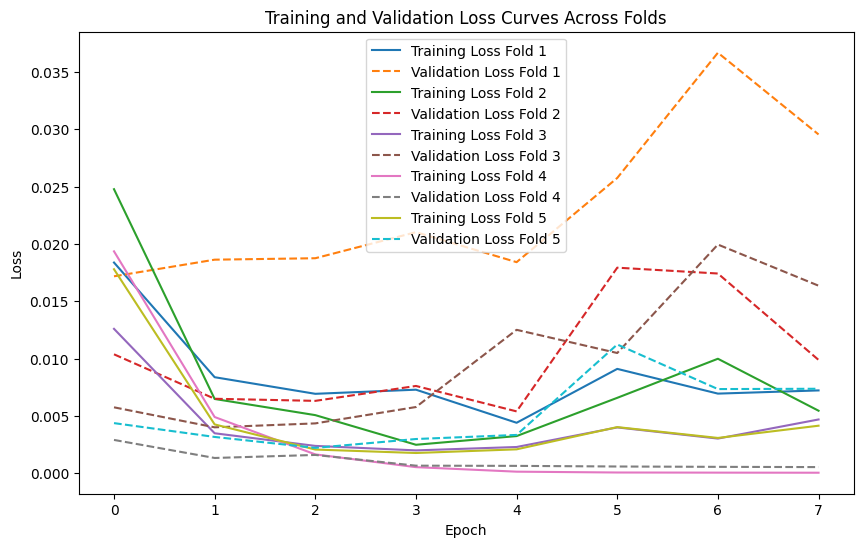

In [8]:
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

k_folds = 5

# Initialize KFold
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Lists to store metrics for each fold
all_precisions = []
all_recalls = []
all_f1_scores = []
fold_loss_history = []  # Store loss for each epoch in each fold
val_loss_history = []  # Store validation loss for each epoch in each fold

for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
    print(f"Fold {fold + 1}/{k_folds}")
    
    # Subset the dataset for train and validation based on indices
    train_dataset = Subset(ner_dataset, train_idx)
    val_dataset = Subset(ner_dataset, val_idx)
    
    # Create DataLoader for train and validation
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    # Train the model
    model.train()
    epoch_loss = []  # Track the loss for each epoch
    epoch_val_loss = []  # Track validation loss for each epoch

    for epoch in range(epochs):
        total_loss = 0
        total_val_loss = 0  # For tracking validation loss

        # Training loop
        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Calculate the average training loss
        avg_loss = total_loss / len(train_loader)
        epoch_loss.append(avg_loss)  # Store loss for this epoch
        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_loss:.4f}")

        # Validation loop
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                # Forward pass
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                val_loss = outputs.loss

                total_val_loss += val_loss.item()

        # Calculate the average validation loss
        avg_val_loss = total_val_loss / len(val_loader)
        epoch_val_loss.append(avg_val_loss)  # Store validation loss for this epoch
        print(f"Epoch {epoch+1}/{epochs}, Validation Loss: {avg_val_loss:.4f}")

    fold_loss_history.append(epoch_loss)  # Store loss history for this fold
    val_loss_history.append(epoch_val_loss)  # Store validation loss history for this fold

    # Evaluation on the validation set
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            logits = logits.detach().cpu().numpy()
            label_ids = labels.cpu().numpy()

            for i in range(len(label_ids)):
                pred_labels = []
                true_label = []
                for j in range(len(label_ids[i])):
                    if label_ids[i][j] != -100:  # Ignoring padding or special tokens
                        true_label.append(label_ids[i][j])
                        pred_label = np.argmax(logits[i][j])
                        pred_labels.append(pred_label)
                predictions.append(pred_labels)
                true_labels.append(true_label)

    # Flatten predictions and true labels
    flat_predictions = [item for sublist in predictions for item in sublist]
    flat_true_labels = [item for sublist in true_labels for item in sublist]

    # Calculate metrics for this fold
    precision = precision_score(flat_true_labels, flat_predictions, average='macro')
    recall = recall_score(flat_true_labels, flat_predictions, average='macro')
    f1 = f1_score(flat_true_labels, flat_predictions, average='macro')

    # Store metrics for this fold
    all_precisions.append(precision)
    all_recalls.append(recall)
    all_f1_scores.append(f1)

    print(f"Fold {fold + 1} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

    # Print classification report for this fold
    print(f"Classification Report for Fold {fold + 1}:\n")
    print(classification_report(flat_true_labels, flat_predictions))

# After cross-validation, calculate average metrics
avg_precision = np.mean(all_precisions)
avg_recall = np.mean(all_recalls)
avg_f1 = np.mean(all_f1_scores)

print(f"\nCross-Validation Results ({k_folds} Folds):")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1-Score: {avg_f1:.4f}")

# Plot loss curves for each fold (training and validation)
plt.figure(figsize=(10, 6))
for fold_idx in range(k_folds):
    plt.plot(fold_loss_history[fold_idx], label=f'Training Loss Fold {fold_idx + 1}')
    plt.plot(val_loss_history[fold_idx], linestyle='--', label=f'Validation Loss Fold {fold_idx + 1}')
plt.title('Training and Validation Loss Curves Across Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [9]:
print(all_precisions)
print(all_recalls)
print(all_f1_scores)



[0.9821072906253534, 0.9902274121798083, 0.9923915488901608, 0.999933368869936, 0.9984458511872454]
[0.9780374934140542, 0.9912090839439417, 0.9844475643883086, 0.9999734169812324, 0.9958325151319669]
[0.9798973975952262, 0.9906522517108295, 0.9883314429066354, 0.9999533839175191, 0.9971242414584314]


# Bucket Analysis

In [7]:
import pandas as pd

df = pd.read_csv('/home/ritisha21089/10k_phrases_batch1.csv')

unique_labels = set()
for labels in df['Labels']:
    labels_list = eval(labels) 
    unique_labels.update(labels_list)

label_map = {label: idx for idx, label in enumerate(sorted(unique_labels))}

print(label_map)


{'DF': 0, 'FORM': 1, 'NAME': 2, 'O': 3, 'PREPROCESSING': 4, 'QUANTITY': 5, 'SIZE': 6, 'STATE': 7, 'UNIT': 8}


In [10]:
#Visualizing entity lengths to define the bin
print(df['Entity_Length'].describe())


count    9500.000000
mean        7.871579
std         3.854460
min         0.000000
25%         5.000000
50%         7.000000
75%        10.000000
max        42.000000
Name: Entity_Length, dtype: float64


In [11]:
# Visualizing token frequency of each label to define the bin
print(label_freq.describe())


count    3098.000000
mean        0.000323
std         0.001433
min         0.000105
25%         0.000105
50%         0.000105
75%         0.000211
max         0.057368
Name: Labels, dtype: float64


In [12]:
# Visualizing token frequency distribution to define the bin
print(token_freq.describe())


count    9497.000000
mean        0.000105
std         0.000002
min         0.000105
25%         0.000105
50%         0.000105
75%         0.000105
max         0.000316
Name: Ingredient_Phrases, dtype: float64


In [9]:
import numpy as np

# to ensure the 'Ingredient_Phrases' column has string values and handles NaNs or other non-string types
df['Ingredient_Phrases'] = df['Ingredient_Phrases'].fillna('').astype(str)

df['Entity_Length'] = df['Ingredient_Phrases'].apply(lambda x: len(x.split())) 

df['Entity_Length_Bucket'] = pd.cut(df['Entity_Length'], bins=[0, 4, 9, np.inf], labels=['short', 'medium', 'long'])

label_freq = df['Labels'].explode().value_counts(normalize=True) 
df['Label_Consistency'] = df['Labels'].apply(lambda x: label_freq[x])  

df['Label_Consistency_Bucket'] = pd.cut(df['Label_Consistency'], bins=[0, 0.0005, 0.005, 0.06], labels=['rare', 'common', 'very_common'])

token_freq = df['Ingredient_Phrases'].explode().value_counts(normalize=True)
df['Token_Frequency'] = df['Ingredient_Phrases'].apply(lambda x: token_freq[x])

df['Token_Frequency_Bucket'] = pd.cut(df['Token_Frequency'], bins=[0, 0.0001, 0.0002, 0.00035], labels=['low', 'medium', 'high'])




In [13]:
df

,Ingredient_Phrases,Quantity,Unit,Ingredient Name,Form,State,Dry/Fresh,Size,Preprocessing,Labels,Entity_Length,Entity_Length_Bucket,Label_Consistency,Label_Consistency_Bucket,Token_Frequency,Token_Frequency_Bucket
0,5 ounces spinach leaves,5,ounces,spinach,leaves,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'FORM']",4,short,0.006211,very_common,0.000105,medium
1,"1 teaspoon wheat germ , if desired -LRB- optio...",1,teaspoon,wheat germ,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'NAME', 'O', 'O',...",10,long,0.004105,common,0.000105,medium
2,1/8 cup pine nuts -LRB- optional -RRB-,1/8,cup,pine nuts,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'NAME', 'O', 'O',...",7,medium,0.009263,very_common,0.000105,medium
3,1/4 cup sunflower oil,1/4,cup,sunflower oil,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'NAME']",4,short,0.057368,very_common,0.000105,medium
4,1 batch jerk sauce -LRB- see recipe above -RRB-,1,batch,jerk sauce,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'NAME', 'O', 'O',...",9,medium,0.007684,very_common,0.000105,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9495,1 lemongrass -LRB- sereh -RRB-,1,NaN,lemongrass,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'NAME', 'O', 'O', 'O']",5,medium,0.001474,common,0.000105,medium
9496,4 ounces anchovies packed in oil,4,ounces,anchovies packed in oil,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'UNIT', 'NAME', 'NAME', 'NAME', '...",6,medium,0.006947,very_common,0.000105,medium
9497,1 baguette -LRB- or other crusty loaf of bread...,1,NaN,baguette,NaN,NaN,NaN,NaN,NaN,"['QUANTITY', 'NAME', 'O', 'O', 'O', 'O', 'O', ...",10,long,0.000316,rare,0.000105,medium
9498,12 toothpicks -LRB- soak them in water -RRB-,12,NaN,toothpicks,NaN,soak them in water,NaN,NaN,NaN,"['QUANTITY', 'NAME', 'O', 'STATE', 'STATE', 'S...",8,medium,0.000421,rare,0.000105,medium


In [15]:
import numpy as np
import pandas as pd

# Ensuring string conversion for 'Ingredient_Phrases'
df['Ingredient_Phrases'] = df['Ingredient_Phrases'].fillna('').astype(str)

# Calculating entity lengths and creating buckets
df['Entity_Length'] = df['Ingredient_Phrases'].apply(lambda x: len(x.split()))
df['Entity_Length_Bucket'] = pd.cut(
    df['Entity_Length'], 
    bins=[0, 4, 9, np.inf], 
    labels=['short', 'medium', 'long']
)

# Label frequency normalization
label_freq = df['Labels'].explode().value_counts(normalize=True)
df['Label_Consistency'] = df['Labels'].apply(lambda x: label_freq.get(x, 0))
df['Label_Consistency_Bucket'] = pd.cut(
    df['Label_Consistency'], 
    bins=[0, 0.0001, 0.001, 0.06],  # Adjusted bins based on stats
    labels=['rare', 'common', 'very_common']
)

# Token frequency normalization
token_freq = df['Ingredient_Phrases'].str.split().explode().value_counts(normalize=True)
df['Token_Frequency'] = df['Ingredient_Phrases'].apply(
    lambda x: np.mean([token_freq.get(token, 0) for token in x.split()])
)
df['Token_Frequency_Bucket'] = pd.cut(
    df['Token_Frequency'], 
    bins=[0, 0.0001, 0.0002, 0.00035],  # Adjusted bins based on stats
    labels=['low', 'medium', 'high']
)

# Ensuring no NaN in buckets
df['Entity_Length_Bucket'] = df['Entity_Length_Bucket'].cat.add_categories('unknown').fillna('unknown')
df['Label_Consistency_Bucket'] = df['Label_Consistency_Bucket'].cat.add_categories('unknown').fillna('unknown')
df['Token_Frequency_Bucket'] = df['Token_Frequency_Bucket'].cat.add_categories('unknown').fillna('unknown')

/home/ritisha21089/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


In [16]:
from sklearn.metrics import classification_report

# Evaluating per bucket
def evaluate_bucket_performance(df, y_true, y_pred, bucket_column):
    unique_buckets = df[bucket_column].unique()
    for bucket in unique_buckets:
        bucket_indices = df[df[bucket_column] == bucket].index
        y_true_bucket = [y_true[i] for i in bucket_indices]
        y_pred_bucket = [y_pred[i] for i in bucket_indices]
        print(f"Performance for {bucket_column}: {bucket}")
        print(classification_report(y_true_bucket, y_pred_bucket, digits=4))


evaluate_bucket_performance(df, flat_true_labels, flat_predictions, 'Entity_Length_Bucket')
evaluate_bucket_performance(df, flat_true_labels, flat_predictions, 'Label_Consistency_Bucket')


Performance for Entity_Length_Bucket: short
              precision    recall  f1-score   support

           0     0.9735    0.9778    0.9756       225
           1     0.9780    0.9823    0.9801       226
           2     0.9731    0.9783    0.9757       554
           3     0.8235    0.8750    0.8485        16
           4     0.9735    0.9583    0.9659       384
           5     0.9500    0.9500    0.9500        20
           6     1.0000    1.0000    1.0000        12

    accuracy                         0.9722      1437
   macro avg     0.9531    0.9603    0.9565      1437
weighted avg     0.9723    0.9722    0.9722      1437

Performance for Entity_Length_Bucket: long
              precision    recall  f1-score   support

           0     0.9827    0.9942    0.9884       342
           1     0.9925    0.9778    0.9851       405
           2     0.9678    0.9737    0.9707       988
           3     0.8182    0.8710    0.8438        31
           4     0.9558    0.9558    0.9558  

# LLM few-shot prompting

In [1]:
import pandas as pd

# Load the dataset (replace with your actual file path)
dataset_path = "/home/ritisha21089/btp/data/10k_data_modified.csv" #"/home/ritisha21089/10k_phrases_batch1.csv"
data = pd.read_csv(dataset_path)

# Ensure labels are properly structured
data['Labels'] = data['Labels'].apply(eval)  # Convert string representation of list to actual list

In [2]:
# Select only the Ingredient_Phrases and Labels columns for few-shot examples
few_shot_examples = data[["Ingredient_Phrases", "Labels"]].iloc[:3].to_dict(orient="records")  # Use the first 3 rows as examples

# Print the few-shot examples
print("Few-shot examples:")
for example in few_shot_examples:
    print(f"Ingredient Phrase: {example['Ingredient_Phrases']}")
    print(f"Labels: {example['Labels']}\n")

Few-shot examples:
Ingredient Phrase: 5 ounces spinach leaves
Labels: ['QUANTITY', 'UNIT', 'NAME', 'FORM']

Ingredient Phrase: 1 teaspoon wheat germ , if desired -LRB- optional -RRB-
Labels: ['QUANTITY', 'UNIT', 'NAME', 'NAME', 'O', 'O', 'O', 'O', 'O', 'O']

Ingredient Phrase: 1/8 cup pine nuts -LRB- optional -RRB-
Labels: ['QUANTITY', 'UNIT', 'NAME', 'NAME', 'O', 'O', 'O']



In [3]:
def create_few_shot_prompt(text, few_shot_examples):
    """
    Generate a few-shot prompt for NER.
    """
    # Task description
    task_description = (
        "Extract entities from the following text and return in JSON format. "
        "The possible entity types are QUANTITY, UNIT, NAME, and STATE. "
        "Here are some examples:\n\n"
    )

    # Add few-shot examples
    examples = "\n".join(
        f"Example {i + 1}:\nText: {ex['Ingredient_Phrases']}\nEntities: {ex['Labels']}"
        for i, ex in enumerate(few_shot_examples)
    )

    # Add the input text for prediction
    input_text = f"\n\nNow, extract entities from the following text:\nText: {text}\nOutput:"

    # Combine everything into a full prompt
    return task_description + examples + input_text

In [4]:
import torch
torch.cuda.set_device(1)  # Set GPU 1 as the active device
print("Now using GPU:", torch.cuda.current_device())

Now using GPU: 1


In [5]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# Load the model and tokenizer (Flan-T5, for example)
model_name = "google/flan-t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")

def few_shot_ner_prediction(text, few_shot_examples):
    """
    Perform Few-Shot NER using HuggingFace models.
    """
    # Generate the few-shot prompt
    prompt = create_few_shot_prompt(text, few_shot_examples)

    # Tokenize the prompt
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to("cuda" if torch.cuda.is_available() else "cpu")

    # Generate prediction
    outputs = model.generate(inputs["input_ids"], max_length=200, temperature=0.0)
    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return prediction

In [6]:
true_labels = []
predicted_labels = []

for _, row in data.iterrows():
    text = row["Ingredient_Phrases"]
    true_labels.append(row["Labels"])  

    prediction = few_shot_ner_prediction(text, few_shot_examples)  

    predicted_labels.append(prediction)  

/home/ritisha21089/.local/lib/python3.8/site-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


In [7]:
predicted_labels[0]

"['QUANTITY', 'NAME', 'FORM']"

In [8]:
true_labels[0]

['QUANTITY', 'UNIT', 'NAME', 'FORM']

In [9]:
print(len(predicted_labels))
print(len(true_labels))

10784
10784


In [10]:
from sklearn.metrics import f1_score, precision_score, recall_score
import re

def parse_predicted_label(pred):
    """
    Safely parse predicted label strings into lists by cleaning and extracting valid list contents.
    """
    if isinstance(pred, str):
        try:
            # Use regex to extract valid list-like content
            pred = re.findall(r"[\w']+", pred)  # Extract words and numbers
        except Exception as e:
            raise ValueError(f"Failed to parse predicted label: {pred}") from e
    return pred

def evaluate_ner(true_labels, predicted_labels):
    """
    Evaluate NER predictions using macro F1, precision, and recall.
    """
    true_flat = []
    pred_flat = []

    # Ensure true_labels and predicted_labels have the same number of samples
    if len(true_labels) != len(predicted_labels):
        raise ValueError(f"Inconsistent number of sequences: true_labels has {len(true_labels)}, predicted_labels has {len(predicted_labels)}")

    for i, (true, pred) in enumerate(zip(true_labels, predicted_labels)):
        # Parse `pred` if it's a string representation of a list
        pred = parse_predicted_label(pred)

        # Ensure both true and pred are lists of strings
        if isinstance(true, list) and isinstance(pred, list):
            # Ensure the sequences are of the same length
            if len(true) != len(pred):
                print(f"Warning: Mismatch in sequence lengths at index {i}. true: {len(true)}, pred: {len(pred)}")
            # Align sequences (truncate or pad)
            min_len = min(len(true), len(pred))
            true_flat.extend(true[:min_len])
            pred_flat.extend(pred[:min_len])
        else:
            raise ValueError("Each element of true_labels and predicted_labels should be a list of strings")

    # Ensure flattened lists have the same length
    if len(true_flat) != len(pred_flat):
        raise ValueError(f"Inconsistent number of samples after flattening: true_flat has {len(true_flat)}, pred_flat has {len(pred_flat)}")

    # Calculate metrics
    macro_f1 = f1_score(true_flat, pred_flat, average="macro", zero_division=1)
    precision = precision_score(true_flat, pred_flat, average="macro", zero_division=1)
    recall = recall_score(true_flat, pred_flat, average="macro", zero_division=1)

    return macro_f1, precision, recall

# Calculate evaluation metrics
macro_f1, precision, recall = evaluate_ner(true_labels, predicted_labels)

print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Macro F1-Score: 0.0000
Precision: 0.0013
Recall: 0.9986


In [32]:
# Error analysis: Compare true labels and predictions
for i, (true, pred) in enumerate(zip(true_labels, predicted_labels)):
    if true != pred:
        print(f"Example {i + 1}:")
        print(f"  Text: {df.iloc[i]['Ingredient_Phrases']}")
        print(f"  True: {true}")
        print(f"  Pred: {pred}")
        print("---------")

In [34]:
for i, (true, pred) in enumerate(zip(true_labels, predicted_labels)):
    if [label.strip().lower() for label in true] != [label.strip().lower() for label in pred]:
        print(f"Example {i + 1}:")
        print(f"  Text: {df.iloc[i]['Ingredient_Phrases']}")
        print(f"  True: {true}")
        print(f"  Pred: {pred}")
        print("---------")

In [35]:
print("Sample true_labels:", true_labels[:3])
print("Sample predicted_labels:", predicted_labels[:3])

Sample true_labels: [['QUANTITY', 'NAME', 'FORM'], ['UNIT', 'NAME']]
Sample predicted_labels: [['QUANTITY', 'NAME', 'FORM'], ['UNIT', 'NAME']]


In [39]:
for i, (true, pred) in enumerate(zip(true_labels, predicted_labels)):
    print(f"Example {i + 1}:")
    print(f"  Text: {data.iloc[i]['Ingredient_Phrases']}")
    print(f"  True: {true}")
    print(f"  Pred: {pred}")
    print("Match: {true == pred}")
    print("---------")

Example 1:
  Text: 5 ounces spinach leaves
  True: ['QUANTITY', 'NAME', 'FORM']
  Pred: ['QUANTITY', 'NAME', 'FORM']
Match: {true == pred}
---------
Example 2:
  Text: 1 teaspoon wheat germ , if desired -LRB- optional -RRB-
  True: ['UNIT', 'NAME']
  Pred: ['UNIT', 'NAME']
Match: {true == pred}
---------


In [40]:
!pip install sklearn-crfsuite

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 7.8 MB/s eta 0:00:00ta 0:00:01

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split

# # Load your dataset
# df = pd.read_csv("path_to_your_dataset.csv")

# Split dataset into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Example structure
print(train_data.head())

                                     Ingredient_Phrases Quantity      Unit  \
8444                       1 tomatoes , cut into eigths        1       NaN   
4619          1 teaspoon fresh basil leaf , sliced thin        1  teaspoon   
7197  1/2 bunch komatsuna greens -LRB- or any greens...        1   package   
9342                 1/4 cup unsalted cashews , roasted      1/4       cup   
8008                1/2 teaspoon dried red chili pepper      1/2  teaspoon   

                  Ingredient Name  Form               State Dry/Fresh Size  \
8444                     tomatoes   NaN    cut into eighths       NaN  NaN   
4619                        basil  leaf         sliced thin     fresh  NaN   
7197  Italian lady finger cookies   NaN                 NaN       NaN  NaN   
9342                      cashews   NaN  unsalted , roasted       NaN  NaN   
8008             red chili pepper   NaN                 NaN       Dry  NaN   

     Preprocessing                                            